# 90803-Machine Learning Foundations with Python
## Good Neighbors Project
### Team 22: Zoe Iseri, Lisa Menda, Nishan Sah

#### Project Overview
The goal of this project is to detect weeks where noise complaints exceed an operational threshold (≥ 3 complaints) so that 311 and city resources are not overburdened. We can use communal resources like awareness or encouraging dialogue between neighbors to address the problems caused by noise.\
Using the 311 noise‐complaint dataset aggregated weekly at the census‐tract level from week 25 of 2015 through week 5 of 2025, we sorted and grouped by census tract and date (week group), then engineered temporal features—1–4-week lags of complaint counts, a 4-week rolling mean and standard deviation, day-of-week and holiday flags, and one-hot neighborhood indicators—while guarding against temporal leakage and ensuring numeric dtypes. We built a clean feature matrix and tested multiple modeling strategies— a baseline RandomForest classifier, GridSearch to find the best parameters, a baseline XGBoost model and a multi-class XGBoost on an ordinal target, SMOTE resampling with binary RandomForest, to prioritize identifying spikes. Aggregating by census tract enables integration of tract-level demographic from the census for bias analyses and supports rolling up to neighborhoods to control for amenities, proximity to public spaces, universities, and nightlife venues as potential noise sources.

<b>Step 1:</b> Import all the libraries

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from holidays import US
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, recall_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import warnings
import csv
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning) #To supress some performance-related warnings

<b>Step 2:</b> Import the complete 311 complaint dataset, and filter the dataset for noise-related complaints

In [6]:
df = pd.read_csv('311Full.csv')
df.head()

,Unnamed: 0,_id,group_id,num_requests,parent_closed,status_name,status_code,dept,request_type_name,request_type_id,...,cross_street_id,city,neighborhood,census_tract,council_district,ward,police_zone,latitude,longitude,geo_accuracy
0,96,97,626501,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,Central Business District,4.200302e+10,6.0,2.0,2.0,40.443452,-80.004199,APPROXIMATE
1,437,438,791540,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
2,483,484,779169,1,t,closed,1,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
3,494,495,744137,1,f,in progress,3,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
4,547,548,641351,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,Highland Park,4.200398e+10,7.0,11.0,5.0,40.482657,-79.916423,APPROXIMATE


In [7]:
noisecat = ['Excessive Noise/Disturbances','Noise']
noisedf = df[df['request_type_name'].isin(noisecat)]

In [8]:
noisedf.groupby('neighborhood')['_id'].count().sort_values(ascending=False)
noisedf.head()

,Unnamed: 0,_id,group_id,num_requests,parent_closed,status_name,status_code,dept,request_type_name,request_type_id,...,cross_street_id,city,neighborhood,census_tract,council_district,ward,police_zone,latitude,longitude,geo_accuracy
0,96,97,626501,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,Central Business District,4.200302e+10,6.0,2.0,2.0,40.443452,-80.004199,APPROXIMATE
1,437,438,791540,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
2,483,484,779169,1,t,closed,1,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
3,494,495,744137,1,f,in progress,3,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NULL_COORDINATES
4,547,548,641351,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,NaN,Pittsburgh,Highland Park,4.200398e+10,7.0,11.0,5.0,40.482657,-79.916423,APPROXIMATE


<b>Step 3:</b> Data Cleaning and Exploratory Data Analysis <br>
Here, we have dropped null values based on unavailable geographical data (census tract) and created columns based on the temporal data (complaint create date). We have added indicators for complaints made in night time (between 9 PM and 5 AM), the day of the week the complaint was made and during holidays. To do this, we have utilized datetime library to get the day of the week and the holidays dataframe that fetches the US holidays.
We then make plots to understand the distribution of data as per the neighborhoods.

In [10]:
noisedf = noisedf.dropna(subset=['census_tract'])

noisedf['create_date_et'] = pd.to_datetime(noisedf['create_date_et'])

noisedf['day_of_week'] = noisedf['create_date_et'].dt.dayofweek
noisedf['day_name'] = noisedf['create_date_et'].dt.day_name()

for i, day in enumerate(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']):
    noisedf[day] = (noisedf['day_of_week'] == i).astype(int)

us_holidays = US()
noisedf['date'] = noisedf['create_date_et'].dt.date
noisedf['is_holiday'] = noisedf['date'].apply(lambda x: x in us_holidays).astype(int)

# Create night indicator (between 9 PM and 5 AM)
noisedf['hour'] = noisedf['create_date_et'].dt.hour
noisedf['is_late_night_next_day'] = ((noisedf['hour'] >= 0) & (noisedf['hour'] < 5)).astype(int)
noisedf['is_night_same_day'] = ((noisedf['hour'] >= 21) & (noisedf['hour'] <= 23)).astype(int)
noisedf['is_weekend'] = noisedf['day_name'].isin(['Saturday','Sunday']).astype(int)
noisedf['is_earlytomidweek'] = noisedf['day_name'].isin(['Monday','Tuesday','Wednesday','Thursday']).astype(int)
noisedf['night_complaints'] = noisedf['is_night_same_day'] + noisedf['is_late_night_next_day']

# Count complaints by day of week
day_counts = noisedf.groupby('day_name').size().reset_index(name='complaint_count')

# Count complaints on holidays vs non-holidays
holiday_counts = noisedf.groupby('is_holiday').size().reset_index(name='complaint_count')
holiday_counts['is_holiday'] = holiday_counts['is_holiday'].map({0: 'Non-Holiday', 1: 'Holiday'})

late_night_counts = noisedf.groupby('night_complaints').size().reset_index(name='complaint_count')
late_night_counts['night_complaints'] = late_night_counts['night_complaints'].map({0: 'Regular Hours', 1: 'Night (9PM-5AM)'})

print("Complaints by Day of Week:")
print(day_counts)
print("\nComplaints on Holidays vs Non-Holidays:")
print(holiday_counts)
print("\nComplaints during Late Night vs Regular Hours:")
print(late_night_counts)

print(f"\nProcessed data saved with {len(noisedf)} rows after removing NULL coordinates.")

Complaints by Day of Week:
    day_name  complaint_count
0     Friday             1320
1     Monday             1353
2   Saturday             1260
3     Sunday             1101
4   Thursday             1240
5    Tuesday             1281
6  Wednesday             1249

Complaints on Holidays vs Non-Holidays:
    is_holiday  complaint_count
0  Non-Holiday             8534
1      Holiday              270

Complaints during Late Night vs Regular Hours:
  night_complaints  complaint_count
0    Regular Hours             5605
1  Night (9PM-5AM)             3199

Processed data saved with 8804 rows after removing NULL coordinates.


In [11]:
noisedf.head()

,Unnamed: 0,_id,group_id,num_requests,parent_closed,status_name,status_code,dept,request_type_name,request_type_id,...,Saturday,Sunday,date,is_holiday,hour,is_late_night_next_day,is_night_same_day,is_weekend,is_earlytomidweek,night_complaints
0,96,97,626501,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,0,1,2022-04-24,0,9,0,0,1,0,0
4,547,548,641351,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,0,1,2022-06-05,0,14,0,0,1,0,0
7,1784,1785,508320,1,f,in progress,3,Police - Zones 1-6,Noise,451,...,0,0,2021-03-18,0,1,1,0,0,1,1
8,2014,2015,668591,1,f,open,0,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,0,0,2022-08-17,0,8,0,0,0,1,0
9,2016,2017,554671,1,f,in progress,3,Police - Zones 1-6,Excessive Noise/Disturbances,297,...,0,0,2021-08-17,0,9,0,0,0,1,0


In [12]:
noisedf.describe()

,Unnamed: 0,_id,group_id,num_requests,status_code,request_type_id,create_date_et,cross_street,street_id,cross_street_id,...,Friday,Saturday,Sunday,is_holiday,hour,is_late_night_next_day,is_night_same_day,is_weekend,is_earlytomidweek,night_complaints
count,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000,8804,0.0,3.000000,3.0,...,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000,8804.000000
mean,402873.070082,402878.253180,516082.878805,1.040323,1.100409,313.215129,2021-02-03 20:43:33.796001792,NaN,3692.666667,0.0,...,0.149932,0.143117,0.125057,0.030668,13.257497,0.139255,0.224103,0.268174,0.581895,0.363358
min,96.000000,97.000000,9417.000000,1.000000,0.000000,297.000000,2015-06-16 17:00:00,NaN,2852.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,165918.750000,165919.750000,334177.250000,1.000000,1.000000,297.000000,2019-04-22 14:52:45,NaN,3287.500000,0.0,...,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,393817.000000,393818.000000,524377.500000,1.000000,1.000000,297.000000,2021-05-18 02:43:30,NaN,3723.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,647598.750000,647599.750000,731478.250000,1.000000,1.000000,297.000000,2023-04-27 09:11:45,NaN,4113.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,815334.000000,815609.000000,926027.000000,27.000000,4.000000,451.000000,2025-02-02 14:35:00,NaN,4503.000000,0.0,...,1.000000,1.000000,1.000000,1.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,255757.715890,255764.254727,250537.391931,0.527198,0.659367,47.270004,NaN,NaN,825.917873,0.0,...,0.357025,0.350212,0.330802,0.172426,7.034839,0.346232,0.417014,0.443034,0.493276,0.480994


[]

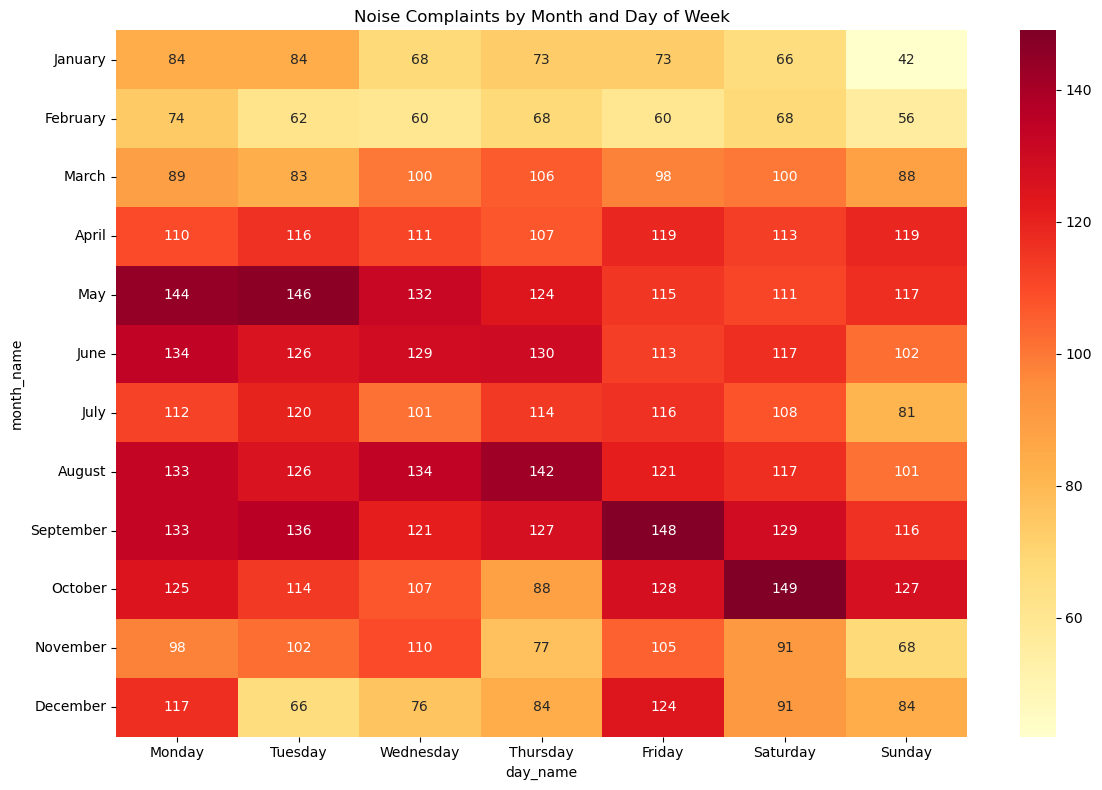

In [13]:
edadf = noisedf.copy()
edadf['month'] = edadf['create_date_et'].dt.month
edadf['month_name'] = edadf['create_date_et'].dt.month_name()
edadf['day_of_week'] = edadf['create_date_et'].dt.day_of_week
edadf['day_name'] = edadf['create_date_et'].dt.day_name()

monthly_daily_pattern = edadf.groupby(['month_name', 'day_name']).size().reset_index(name='count')

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = monthly_daily_pattern.pivot_table(
    index='month_name', 
    columns='day_name', 
    values='count',
    aggfunc='sum',
    fill_value=0
)

heatmap_data = heatmap_data.reindex(month_order)
heatmap_data = heatmap_data[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Noise Complaints by Month and Day of Week')
plt.tight_layout()
plt.plot()

[]

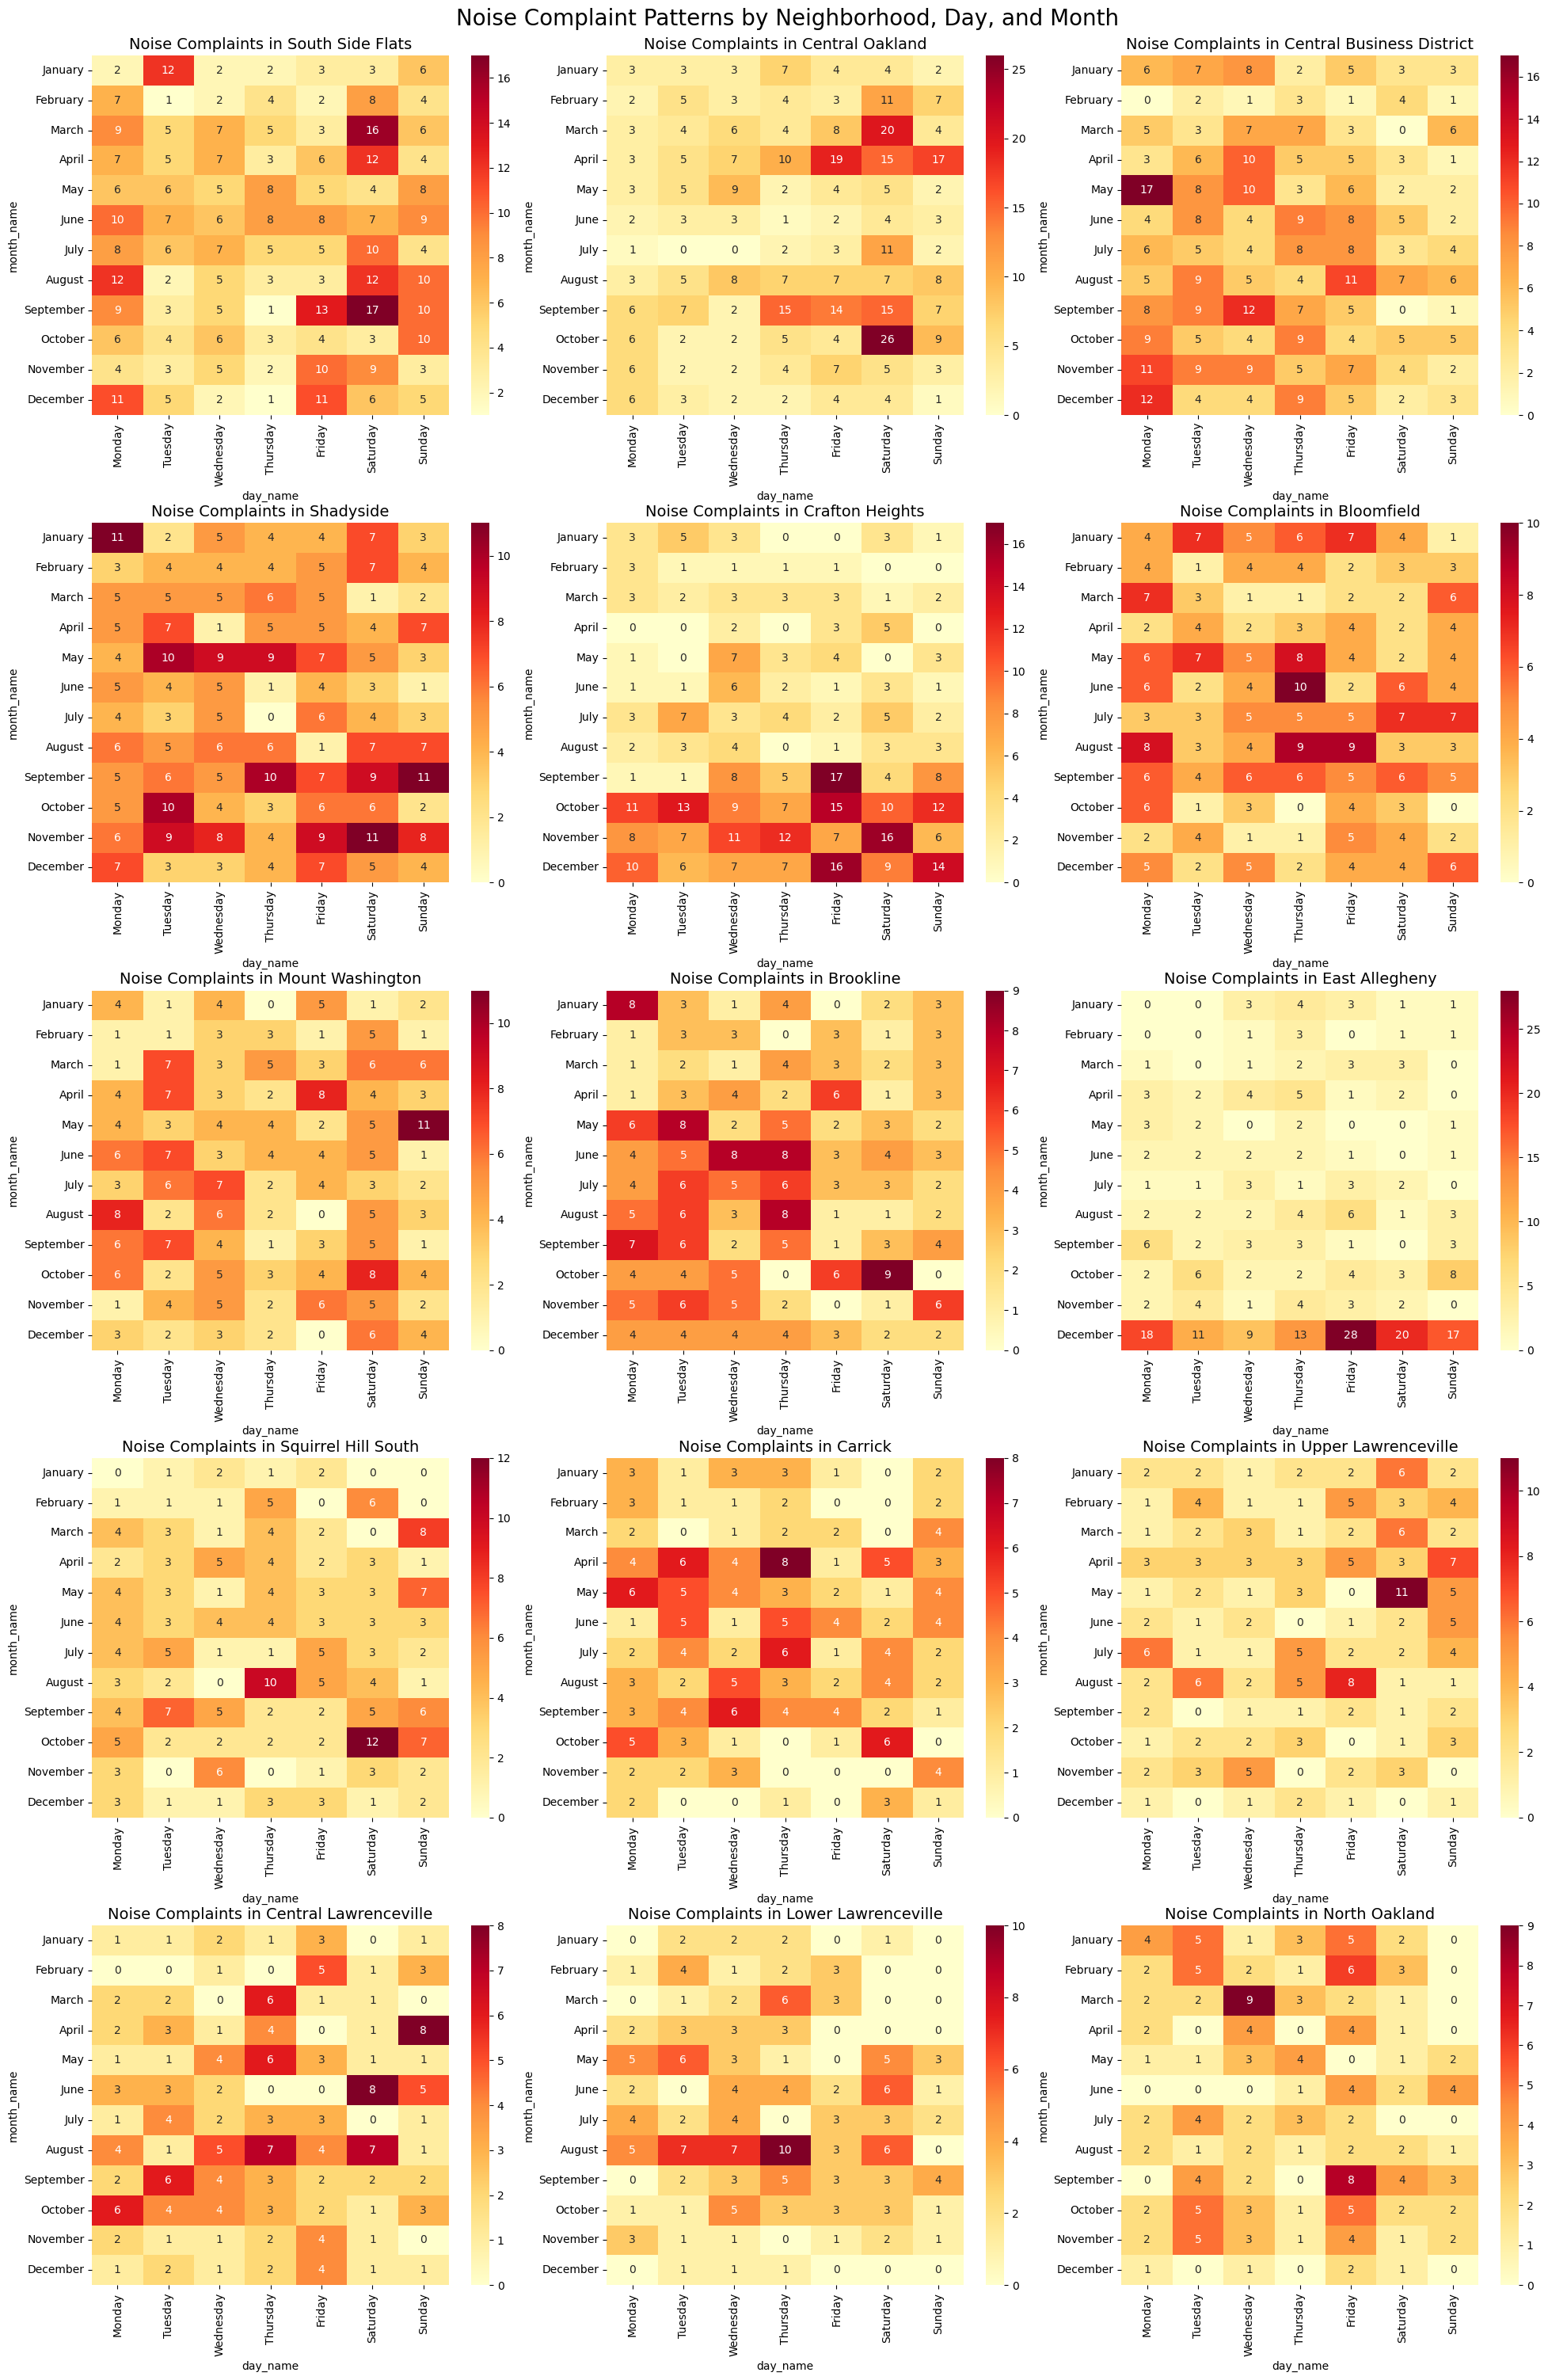

In [14]:
top_neighborhoods = edadf['neighborhood'].value_counts().head(15).index.tolist()

plt.figure(figsize=(20, 30))

for i, neighborhood in enumerate(top_neighborhoods):
    neighborhood_data = edadf[edadf['neighborhood'] == neighborhood]
    
    heatmap_data = pd.crosstab(
        index=neighborhood_data['month_name'],
        columns=neighborhood_data['day_name'],
        values=neighborhood_data['_id'],
        aggfunc='count'
    ).fillna(0)
    
    heatmap_data = heatmap_data.reindex(month_order)
    heatmap_data = heatmap_data[day_order]
    
    plt.subplot(5, 3, i+1)
    
    sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='YlOrRd', cbar=True)
    plt.title(f'Noise Complaints in {neighborhood}', fontsize=14)
    plt.tight_layout()

plt.suptitle('Noise Complaint Patterns by Neighborhood, Day, and Month', fontsize=20, y=1)
plt.subplots_adjust(top=0.98, hspace=0.3)
plt.plot()

We can clearly observe that the patterns of noise complaints for each neighborhoood differ in different months. This strengthens the need to have more granular analysis that is specific to different contexts.

<b>Step 4:</b> We construct a dataframe organized by weeks and census tracts. First, we identify the earliest week when complaint documentation began, then generate a sequential column for every subsequent week (formatted as year + week number, ranging from 1-52 or 53 for leap years). This is joined with census tract data in a one-to-many relationship. This approach allows us to analyze both periods of complaint inactivity and complaint spikes across different geographic areas, providing a comprehensive temporal and spatial view of the data patterns. We then do the same for the original dataframe, noisedf and merge the two dataframes based on the week group with the weekly aggregates. To get the week number of the year for the set date, we have used the ISO week identifiers. The final dataframe that incorporates all of these data is <i>weeks_tracts</i>.

In [17]:
TRACT_COL = "census_tract"          
noisedf[TRACT_COL] = noisedf[TRACT_COL].astype(str).str.zfill(11)

start_monday = (
    noisedf["create_date_et"].min()
    .to_period("W")
    .start_time
)
end_monday = (
    noisedf["create_date_et"].max()
    .to_period("W")
    .start_time
)

all_weeks = (
    pd.date_range(start_monday, end_monday, freq="W-MON")
    .to_series(name="week_start")
)

all_weeks = (
    all_weeks
      .to_frame()
      .assign(
          iso_year = lambda d: d["week_start"].dt.isocalendar().year,
          iso_week = lambda d: d["week_start"].dt.isocalendar().week,
      )
)

all_weeks["week_group"] = (
    all_weeks["iso_year"]*100 + all_weeks["iso_week"]
)
all_weeks = all_weeks[["week_group", "week_start"]]

tracts = (
    pd.Series(noisedf[TRACT_COL].unique(), name="census_tract")
      .to_frame()
)


weeks_tracts = (
    all_weeks.assign(key=1)
    .merge(tracts.assign(key=1), on="key", how="outer")
    .drop("key", axis=1)
    .sort_values(["week_group", "census_tract"])
    .reset_index(drop=True)
)

print("Shape: ", weeks_tracts.shape)
weeks_tracts['week_tract'] = weeks_tracts['week_group'].astype(str) + weeks_tracts['census_tract'].astype(str)

Shape:  (69917, 3)


In [18]:
noisedf["create_date_et"] = pd.to_datetime(noisedf["create_date_et"])

# Monday of the ISO-week the complaint occurred in
noisedf["week_start"] = (
    noisedf["create_date_et"]
      .dt.to_period("W")           # ISO week period
      .apply(lambda p: p.start_time)  # Monday date
)

# Numeric week_group = YYYY * 100 + WW   (e.g. 202525 means ISO-week 25 of 2025)
iso = noisedf["week_start"].dt.isocalendar()
noisedf["week_group"] = iso.year * 100 + iso.week

print(noisedf[["create_date_et", "week_start", "week_group"]].head())

       create_date_et week_start  week_group
0 2022-04-24 09:56:00 2022-04-18      202216
4 2022-06-05 14:43:00 2022-05-30      202222
7 2021-03-18 01:43:00 2021-03-15      202111
8 2022-08-17 08:10:00 2022-08-15      202233
9 2021-08-17 09:51:00 2021-08-16      202133


In [19]:
noisedf = noisedf.dropna(subset=['census_tract'])
noisedf['week_tract'] = noisedf['week_group'].astype(str) + noisedf['census_tract'].astype(str)

In [20]:
weekly_noisedf = noisedf.groupby('week_tract').agg({'is_holiday': 'sum', 
                                                    'is_weekend':'sum',
                                                    'is_earlytomidweek':'sum',
                                                    'Friday':'sum',
                                                    'night_complaints':'sum',
                                                   })
weekly_noisedf = pd.merge(
    noisedf[['week_tract', 'census_tract','week_group']],
    weekly_noisedf,
    on='week_tract',
    how='right'
)

In [21]:
weeks_tracts = pd.merge(
    weeks_tracts,
    weekly_noisedf[['week_tract','is_holiday', 'is_weekend','is_earlytomidweek', 'Friday', 'night_complaints']],
    on='week_tract',
    how='left'
)

In [22]:
weeks_tracts['totalcomplaints'] = weeks_tracts['is_weekend'] + weeks_tracts['Friday'] + weeks_tracts['is_earlytomidweek']

In [23]:
weeks_tracts = weeks_tracts.fillna(0)
weeks_tracts.shape

(72095, 10)

<b>Step 5: </b>We create a function that helps us format the census_tract key in a way that aligns with the information in the census database. We also aggregate neighborhood columns as one-hot encoded, i.e. if there was any complaint from a given neighborhood in a given week, it is assigned 1, otherwise 0. Then we merge the encoded columns to the main dataframe.

In [25]:
def format_census_tract(val):
    '''
    Converts census tract to 11-digit string for merging.
    '''
    try:
        return "{:011.0f}".format(float(val))
    except:
        return None

weeks_tracts['census_tract'] = weeks_tracts['census_tract'].apply(format_census_tract)

print(weeks_tracts[['census_tract', 'week_tract']].dropna().head())

  census_tract           week_tract
0  42003010300  20152542003010300.0
1  42003020100  20152542003020100.0
2  42003020300  20152542003020300.0
3  42003030500  20152542003030500.0
4  42003040200  20152542003040200.0


In [26]:
NBHD_COL  = "neighborhood"    

noisedf[TRACT_COL] = (
    noisedf[TRACT_COL]
      .astype(str)
      .str.zfill(11)           
)
noisedf[NBHD_COL] = (
    noisedf[NBHD_COL]
      .str.strip()
      .str.title()
)

# Get every unique pair of census tract and neighborhoods
tract_neigh = (
    noisedf[[TRACT_COL, NBHD_COL]]
      .dropna()
      .drop_duplicates()
      .reset_index(drop=True)
)

print("Unique (tract, neighbourhood) pairs:", len(tract_neigh))
display(tract_neigh.head())

Unique (tract, neighbourhood) pairs: 183


,census_tract,neighborhood
0,42003020100.0,Central Business District
1,42003980100.0,Highland Park
2,42003220600.0,Central Northside
3,42003110200.0,Highland Park
4,42003562400.0,Bon Air


In [27]:
tract_neigh = pd.get_dummies(tract_neigh, columns=['neighborhood'],drop_first=True,sparse=False)

In [28]:
tract_neigh.head()

,census_tract,neighborhood_Allegheny West,neighborhood_Allentown,neighborhood_Arlington,neighborhood_Arlington Heights,neighborhood_Banksville,neighborhood_Bedford Dwellings,neighborhood_Beechview,neighborhood_Beltzhoover,neighborhood_Bloomfield,...,neighborhood_Summer Hill,neighborhood_Swisshelm Park,neighborhood_Terrace Village,neighborhood_Troy Hill,neighborhood_Upper Hill,neighborhood_Upper Lawrenceville,neighborhood_West End,neighborhood_West Oakland,neighborhood_Westwood,neighborhood_Windgap
0,42003020100.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,42003980100.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,42003220600.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,42003110200.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,42003562400.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
tract_neigh['census_tract'] = tract_neigh['census_tract'].apply(format_census_tract)

In [30]:
weeks_tracts = pd.merge(
    weeks_tracts,
    tract_neigh,
    on='census_tract',
    how='left'
)

<b>Step 6: </b>We now get demographic data from the census by leveraging the API. For this project, we are prioritizing to use income levels and dominant age groups in a census tract to address potential sources of bias. We first fetch the census data, merge it with our dataframe, and then calculate the dominant demographic by income levels and age groups. We have used the B19037 group of the American Community Survey 2022 for our analysis.

In [32]:
import requests

# variable labels for B19037 group
meta_url = "https://api.census.gov/data/2023/acs/acs5/groups/B19037.json"
meta_response = requests.get(meta_url)
variables = meta_response.json()['variables']
label_map = {var_code: info['label']
             for var_code, info in variables.items()
             if var_code.endswith('E')
            }

api_key = 'b689499d90aa4d0344f4afb6768ab42bffb8b5c1'
url = f"https://api.census.gov/data/2023/acs/acs5?get=group(B19037)&for=tract:*&in=state:42+county:003&key={api_key}"
response = requests.get(url)

if response.status_code == 200:
    print("Census API call successful!")
else:
    print(f"API Error {response.status_code}: {response.text}")

headers = response.json()[0]
rows = response.json()[1:]
censusdf = pd.DataFrame(rows, columns=headers)

keep_cols = [col for col in censusdf.columns if col.endswith('E')] + ['state', 'county', 'tract']
censusdf = censusdf[keep_cols]

censusdf['census_tract'] = (censusdf['state'].str.zfill(2) + censusdf['county'].str.zfill(3) + censusdf['tract'].str.zfill(6))
censusdf.drop(columns=['state', 'county', 'tract'], inplace=True)

for col in censusdf.columns:
    if col != 'census_tract':
        censusdf[col] = pd.to_numeric(censusdf[col], errors='coerce')

censusdf.rename(columns=label_map, inplace=True)

print("Demographic data sample:")
censusdf.head()

Census API call successful!
Demographic data sample:


,Estimate!!Total:,Estimate!!Total:!!Householder under 25 years:,"Estimate!!Total:!!Householder under 25 years:!!Less than $10,000","Estimate!!Total:!!Householder under 25 years:!!$10,000 to $14,999","Estimate!!Total:!!Householder under 25 years:!!$15,000 to $19,999","Estimate!!Total:!!Householder under 25 years:!!$20,000 to $24,999","Estimate!!Total:!!Householder under 25 years:!!$25,000 to $29,999","Estimate!!Total:!!Householder under 25 years:!!$30,000 to $34,999","Estimate!!Total:!!Householder under 25 years:!!$35,000 to $39,999","Estimate!!Total:!!Householder under 25 years:!!$40,000 to $44,999",...,"Estimate!!Total:!!Householder 65 years and over:!!$45,000 to $49,999","Estimate!!Total:!!Householder 65 years and over:!!$50,000 to $59,999","Estimate!!Total:!!Householder 65 years and over:!!$60,000 to $74,999","Estimate!!Total:!!Householder 65 years and over:!!$75,000 to $99,999","Estimate!!Total:!!Householder 65 years and over:!!$100,000 to $124,999","Estimate!!Total:!!Householder 65 years and over:!!$125,000 to $149,999","Estimate!!Total:!!Householder 65 years and over:!!$150,000 to $199,999","Estimate!!Total:!!Householder 65 years and over:!!$200,000 or more",Geographic Area Name,census_tract
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NaN,42003010301
1,313,89,0,0,0,16,0,0,0,10,...,0,0,8,0,0,0,0,0,NaN,42003010302
2,2205,261,102,42,0,0,0,0,11,0,...,9,10,31,29,0,0,57,88,NaN,42003020100
3,1227,32,0,0,0,0,0,0,0,0,...,0,5,8,0,15,0,0,2,NaN,42003020300
4,1604,144,31,46,11,0,0,7,0,0,...,32,7,82,0,0,19,18,12,NaN,42003030500


In [33]:
weeks_tracts = weeks_tracts.merge(censusdf, on='census_tract', how='inner')

demo_cols = [col for col in weeks_tracts.columns if 'Householder' in col or 'Median' in col]
print("Sample of demographic features:")
weeks_tracts[['census_tract'] + demo_cols].head(3)

Sample of demographic features:


,census_tract,Estimate!!Total:!!Householder under 25 years:,"Estimate!!Total:!!Householder under 25 years:!!Less than $10,000","Estimate!!Total:!!Householder under 25 years:!!$10,000 to $14,999","Estimate!!Total:!!Householder under 25 years:!!$15,000 to $19,999","Estimate!!Total:!!Householder under 25 years:!!$20,000 to $24,999","Estimate!!Total:!!Householder under 25 years:!!$25,000 to $29,999","Estimate!!Total:!!Householder under 25 years:!!$30,000 to $34,999","Estimate!!Total:!!Householder under 25 years:!!$35,000 to $39,999","Estimate!!Total:!!Householder under 25 years:!!$40,000 to $44,999",...,"Estimate!!Total:!!Householder 65 years and over:!!$35,000 to $39,999","Estimate!!Total:!!Householder 65 years and over:!!$40,000 to $44,999","Estimate!!Total:!!Householder 65 years and over:!!$45,000 to $49,999","Estimate!!Total:!!Householder 65 years and over:!!$50,000 to $59,999","Estimate!!Total:!!Householder 65 years and over:!!$60,000 to $74,999","Estimate!!Total:!!Householder 65 years and over:!!$75,000 to $99,999","Estimate!!Total:!!Householder 65 years and over:!!$100,000 to $124,999","Estimate!!Total:!!Householder 65 years and over:!!$125,000 to $149,999","Estimate!!Total:!!Householder 65 years and over:!!$150,000 to $199,999","Estimate!!Total:!!Householder 65 years and over:!!$200,000 or more"
0,42003020100,261,102,42,0,0,0,0,11,0,...,16,0,9,10,31,29,0,0,57,88
1,42003020300,32,0,0,0,0,0,0,0,0,...,11,0,0,5,8,0,15,0,0,2
2,42003020300,32,0,0,0,0,0,0,0,0,...,11,0,0,5,8,0,15,0,0,2


In [34]:
low_income_brackets = ['$10,000 to $14,999', '$15,000 to $19,999', '$20,000 to $24,999', '$25,000 to $29,999']
mid_income_brackets = ['$30,000 to $34,999', '$35,000 to $39,999', '$40,000 to $44,999',
                       '$45,000 to $49,999', '$50,000 to $59,999', '$60,000 to $74,999']
high_income_brackets = ['$75,000 to $99,999', '$100,000 to $124,999', '$125,000 to $149,999',
                        '$150,000 to $199,999', '$200,000 or more']

def find_cols_by_bracket(bracket_list):
    '''
    Group income brackets into tiers based on aggregated counts
    '''
    return [col for col in weeks_tracts.columns if any(bracket in col for bracket in bracket_list)]

low_cols = find_cols_by_bracket(low_income_brackets)
mid_cols = find_cols_by_bracket(mid_income_brackets)
high_cols = find_cols_by_bracket(high_income_brackets)

weeks_tracts['low_income_total'] = weeks_tracts[low_cols].astype(float).sum(axis=1)
weeks_tracts['mid_income_total'] = weeks_tracts[mid_cols].astype(float).sum(axis=1)
weeks_tracts['high_income_total'] = weeks_tracts[high_cols].astype(float).sum(axis=1)

In [35]:
under_25_brackets = ['Householder under 25 years:']
age_25_44_brackets = ['Householder 25 to 44 years:']
age_45_64_brackets = ['Householder 45 to 64 years:']
age_65_over_brackets = ['Householder 65 years and over:']

def find_cols_by_label(label_list):
    '''
    Group age brackets into categories based on aggregated counts
    '''
    return [col for col in weeks_tracts.columns if any(label in col and '$' in col for label in label_list)]

under_25_cols = find_cols_by_label(under_25_brackets)
age_25_44_cols = find_cols_by_label(age_25_44_brackets)
age_45_64_cols = find_cols_by_label(age_45_64_brackets)
age_65_over_cols = find_cols_by_label(age_65_over_brackets)

weeks_tracts['total_under_25'] = weeks_tracts[under_25_cols].astype(float).sum(axis=1)
weeks_tracts['total_25_44'] = weeks_tracts[age_25_44_cols].astype(float).sum(axis=1)
weeks_tracts['total_45_64'] = weeks_tracts[age_45_64_cols].astype(float).sum(axis=1)
weeks_tracts['total_65_over'] = weeks_tracts[age_65_over_cols].astype(float).sum(axis=1)

In [36]:
def classify_income_aggregate(row):
    '''
    Classify each census tract based on the largest tier total. Returns key with highest value.
    '''
    totals = {'Low Income': row['low_income_total'],
              'Mid Income': row['mid_income_total'],
              'High Income': row['high_income_total']
             }
    return max(totals, key=totals.get) 

weeks_tracts['income_tier'] = weeks_tracts.apply(classify_income_aggregate, axis=1)

In [37]:
def classify_age_aggregate(row):
    '''
    Classify each tract based on the largest age group total. Returns key with highest value.
    '''
    totals = {'Under 25': row['total_under_25'],
              'Age 25–44': row['total_25_44'],
              'Age 45–64': row['total_45_64'],
              'Age 65+': row['total_65_over']
             }
    return max(totals, key=totals.get)

weeks_tracts['dominant_age_group'] = weeks_tracts.apply(classify_age_aggregate, axis=1)

In [38]:
weeks_tracts[['census_tract','dominant_age_group','income_tier']].head()

,census_tract,dominant_age_group,income_tier
0,42003020100,Age 25–44,High Income
1,42003020300,Age 25–44,High Income
2,42003020300,Age 25–44,High Income
3,42003030500,Age 25–44,Mid Income
4,42003040200,Under 25,Mid Income


#### Label and Feature Matrix Construction
<b>Step 7:</b> We now begin building the model. This is how the features have been distributed. We can see that there are lots of 0s and 1s and only some spikes. This brings out a caveat in our analysis, Pittsburgh has relatively less noise complaints than other places. However, we still want to pursue a model that can detect potential spikes of complaints in the future. Because of this reason, we are considering weeks with 0-2 complaints in a census tract as low complaints, and weeks with more than 2 complaints as a spike in our labels. The label will be a binary indicator that will be assigned 0 and 1 respectively.

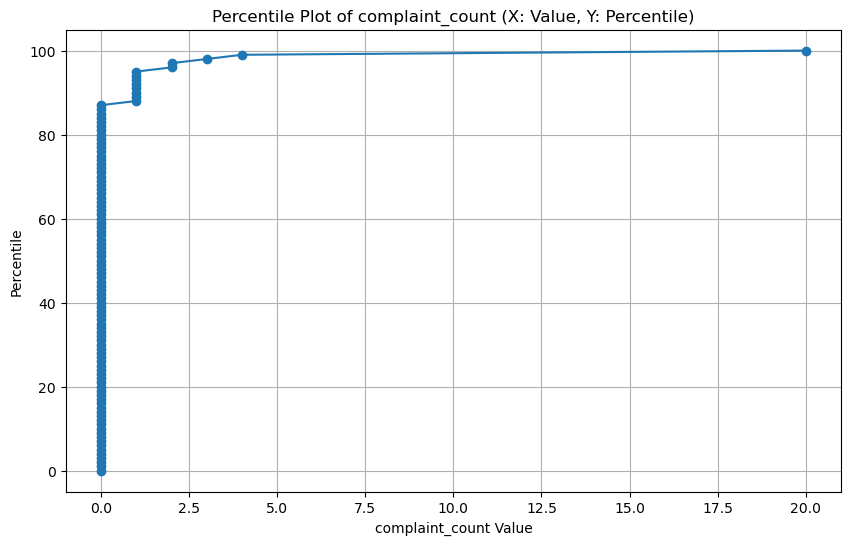

In [40]:
percentiles = np.percentile(weeks_tracts['totalcomplaints'], np.arange(0, 101, 1))

plt.figure(figsize=(10, 6))
plt.plot(percentiles, np.arange(0, 101, 1), marker='o')
plt.title('Percentile Plot of complaint_count (X: Value, Y: Percentile)')
plt.xlabel('complaint_count Value')
plt.ylabel('Percentile')
plt.grid(True)
plt.show()

In [41]:
featureMatrix = weeks_tracts.copy()

# Binary label: High = top tertile
featureMatrix['label'] = (featureMatrix['totalcomplaints'] > 2).astype(int)

#### Feature Matrix and Feature Engineering 
<b>Step 8:</b> We now design the feature matrix. The rationale for our feature selection is given below:

Raw timestamps and counts alone rarely capture the temporal patterns, seasonality, and local context needed to **anticipate** complaint surges. Feature engineering transforms the weekly aggregated counts into actionable signals by:

- **Encoding temporal dynamics** (lags & rolling statistics) so the model “remembers” recent trends  
- **Flagging recurrent patterns** (weekends, holidays, Fridays) that drive predictable noise spikes  
- **Embedding spatial context** (neighborhood one-hots and their lags) to localize alerts
---

<b>Lag Features: Capturing Momentum & Persistence</b>

1. **`totalcomplaints_lag1` … `totalcomplaints_lag4`**  
   - _What?_ The number of complaints in the same tract 1, 2, 3, and 4 weeks ago  
   - _Why?_ Noise problems often persist: a busy week tends to be followed by another busy week.  Multi-week lags let the model gauge whether a spike is a one-off or part of a sustained trend.  
   - _Interpretation:_ If a bar generated 5 complaints two weeks ago and 4 last week, you’ll likely see elevated complaints again this week.

2. **`ma4` (4-week rolling mean)**  
   - _What?_ The average of the last 4 weeks’ counts (excluding the current week)  
   - _Why?_ Smooths out week-to-week volatility and highlights the underlying trend.  
   - _Interpretation:_ Helps distinguish a sudden single-week event (concert) from a season-long noise issue (outdoor festival season).

3. **`std4` (4-week rolling standard deviation)**  
   - _What?_ The volatility of complaint counts over the past 4 weeks  
   - _Why?_ High variability often precedes unpredictable spikes, which can be harder to forecast but crucial to catch early.  
   - _Interpretation:_ A tract with wildly fluctuating counts may need more flexible resource allocation than one with steady, low-variance noise.

---

<b>Calendar & Event Flags: Seasonality Signals</b>

- **`weekofyear` & `month`**  
  - Encode annual seasonality (e.g., summer festivals, holiday parties)  
  - _Interpretation:_ Week 52 (New Year’s Eve) typically sees spikes across many tracts.

- **`holiday_complaint_prev`**  
  - 1 if the prior week contained a public holiday  
  - _Interpretation:_ Residents may host gatherings on the weekend before or after a holiday, driving complaints.

- **`weekend_complaint_prev`**  
  - 1 if there were any weekend (Sat/Sun) complaints last week  
  - _Interpretation:_ Nightlife-driven complaints often concentrate on weekends.

- **`night_complaint_prev`**  
  - 1 if any complaints occurred after 10 pm last week  
  - _Interpretation:_ Late-night noise (bars, clubs) tends to repeat.

- **`friday_complaint_prev`**  
  - 1 if any complaints occurred on the previous Friday  
  - _Interpretation:_ Paid “Happy Hours” and end-of-work parties frequently start noise issues on Friday.

---

<b>Neighborhood One-Hot & Lagged Indicators</b>

- **`neighborhood_<Name>`**  
  - One-hot encoding of each tract’s neighborhood  
  - _Why?_ Captures baseline noise levels and local land use (residential vs. entertainment districts).  

- **`<neighborhood>_lag1`**  
  - The same neighborhood indicator lagged one week  
  - _Why?_ Detects sudden activation of a neighborhood-specific noise source (e.g., new construction or event venue).

---

By combining temporal lags, rolling summaries, calendar flags, and spatial context, we equip our models to distinguish routine seasonal patterns from emerging complaints—enabling proactive deployment of 311 resources and more equitable, data-driven noise management.

Note: We discovered that the midweek data was causing data leakage, so we opted out of using it in our analysis.

In [43]:
# Calendar features known in advance that will be used to build lag features
featureMatrix['weekofyear'] = featureMatrix['week_start'].dt.isocalendar().week.astype(int)
featureMatrix['month']      = featureMatrix['week_start'].dt.month
if 'is_holiday' in featureMatrix.columns:
    featureMatrix['holiday_complaint_prev'] = featureMatrix['is_holiday']
    featureMatrix['weekend_complaint_prev'] = featureMatrix['is_weekend']
if 'night_complaints' in featureMatrix.columns:
    featureMatrix['night_complaint_prev'] = featureMatrix['night_complaints']
if 'is_earlytomidweek' in featureMatrix.columns:
    featureMatrix['midweek_complaint_prev'] = featureMatrix['is_earlytomidweek']
if 'Friday' in featureMatrix.columns:
    featureMatrix['friday_complaint_prev'] = featureMatrix['Friday']

In [44]:
# Define all columns that need a 1-week lag
flag_cols = [
    'night_complaint_prev',
    'midweek_complaint_prev',
    'weekend_complaint_prev',
    'holiday_complaint_prev',
    'friday_complaint_prev',
]

onehot_cols = [c for c in featureMatrix if c.startswith('neighborhood_')]

cols_to_lag1 = ['totalcomplaints'] + flag_cols + onehot_cols

for col in cols_to_lag1:
    featureMatrix[f'{col}_lag1'] = (
        featureMatrix
          .groupby('census_tract')[col]
          .shift(1)
    )

for lag in (2, 3, 4):
    featureMatrix[f'totalcomplaints_lag{lag}'] = (
        featureMatrix
          .groupby('census_tract')['totalcomplaints']
          .shift(lag)
    )

count_col = 'totalcomplaints'    
for lag in range(1, 5):
    featureMatrix[f'count_lag{lag}'] = (
        featureMatrix
          .groupby('census_tract')[count_col]
          .shift(lag)
    )
# rolling mean & std over the *previous* 4 weeks
grp = featureMatrix.groupby('census_tract')['totalcomplaints'].shift(1)
featureMatrix['ma4']  = grp.rolling(4, min_periods=1).mean().reset_index(level=0, drop=True)
featureMatrix['std4'] = grp.rolling(4, min_periods=1).std().reset_index(level=0, drop=True)

# Fill NaNs (first week for each tract) with zero
lag_cols = [c for c in featureMatrix.columns if c.endswith('_lag1') or c.startswith('totalcomplaints_lag')]
featureMatrix[lag_cols + ['ma4','std4']] = featureMatrix[lag_cols + ['ma4','std4']].fillna(0)

In [45]:
X = featureMatrix[[c for c in (
        [f'totalcomplaints_lag{l}' for l in range(1,5)] +
        ['ma4','std4','weekofyear','month','holiday_complaint_prev','weekend_complaint_prev','night_complaint_prev',
         'friday_complaint_prev'] +
        onehot_cols
    ) if c in featureMatrix.columns]].copy()

y = featureMatrix['label']
mask = X.notna().all(axis=1)
X, y = X.loc[mask], y.loc[mask]
print('Final modelling matrix:', X.shape)

Final modelling matrix: (76106, 101)


In [46]:
# Since some columns are of object datatype and need to be converted to float for analysis
for col in X.select_dtypes('object').columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')    

#### Model Construction
<b>Step 9: </b>We create different models and fine-tune their hyperparameters. The rationale for our model selection is given below:
**RandomForestClassifier**  
- *Robust ensemble*: Combines hundreds of decision trees to smooth out noise in our 1–4-week lags, rolling statistics and binary flags, capturing non-linear interactions without extensive feature scaling.  
- *Minimal assumptions*: Handles mixed numeric and dummy-encoded spatial features natively, making it easy to plug in our weekly counts, neighborhood one-hots and date flags.  
- *Interpretability & speed*: Offers built-in feature-importance scores for policy teams, while training quickly even on large resampled datasets.

**XGBoostClassifier**  
- *Gradient boosting power*: Sequentially builds trees that correct predecessor errors, extracting subtle signals in imbalanced, time-series complaint data for sharper “High-week” detection.  
- *Built-in regularization*: L1/L2 penalties plus shrinkage and subsampling guard against over-fitting on rare events, critical when spikes are unpredictable.  
- *Efficiency & flexibility*: Histogram-based split finding and `scale_pos_weight` support make it fast and imbalance-aware, with options to swap to Poisson loss for direct count forecasting.

**GridSearchCV**  
- *Systematic tuning*: Exhaustively sweeps key hyperparameters (tree depth, leaf size, feature‐and‐row subsampling) to maximize cross-validated recall on “High” weeks.  
- *Stratified folds*: Ensures each fold preserves the 2 % “High” class ratio, giving reliable hyperparameter performance estimates for rare-event recall.  
- *Reproducibility & traceability*: Consistent CV splits and fixed random seeds make the tuning process transparent and the chosen settings verifiable.

**SMOTE Sampling**  
- *Synthetic oversampling*: Generates new “High”-week examples to address the 98 % majority class imbalance, boosting model recall on scarce spikes.  
- *Pipeline-safe*: Applied only to the training split in cross-validation, preventing leakage while enriching the minority class signal.  
- *Bias control*: Helps the model learn from a broader variety of spike scenarios—critical for equitable noise-management across diverse census tracts.  


In [48]:
# Train / test temporal split
split = int(len(X)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

rf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("\n-- Base RandomForest Classification Report --")
print(classification_report(y_test, y_pred, target_names=['Not‑High','High']))


-- Base RandomForest Classification Report --
              precision    recall  f1-score   support

    Not‑High       0.99      1.00      1.00     14613
        High       0.96      0.83      0.89       609

    accuracy                           0.99     15222
   macro avg       0.97      0.91      0.94     15222
weighted avg       0.99      0.99      0.99     15222



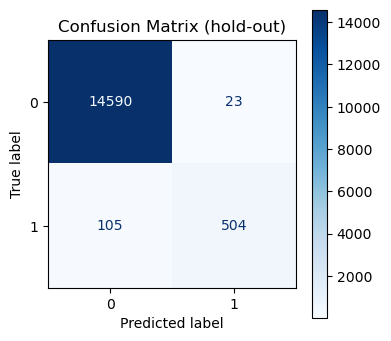

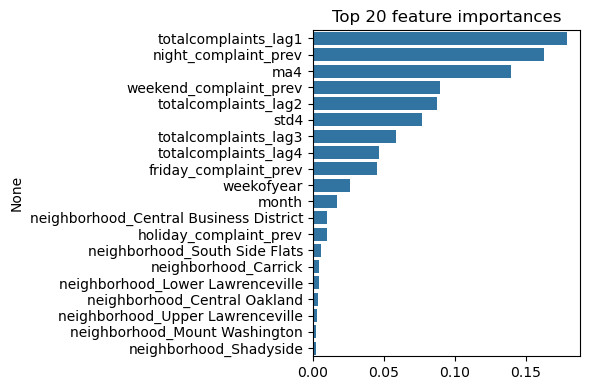

In [49]:
fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (hold‑out)')
plt.show()

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:20]
plt.figure(figsize=(6,4))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Top 20 feature importances')
plt.tight_layout()
plt.show()

In [71]:
param_grid = {
    "n_estimators": [400, 600, 800],
    "max_depth": [None, 8, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
gscv = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring=make_scorer(recall_score),
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
gscv.fit(X_train, y_train)
print("Best params:", gscv.best_params_)
print("Best CV recall:", gscv.best_score_)

best_rf = gscv.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print("\n-- Tuned RandomForest using GridSearch Classification Report --")
print(classification_report(y_test, y_pred_tuned, target_names=['Not‑High','High']))

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best params: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 5, 'n_estimators': 800}
Best CV recall: 0.9276195604099763

-- Tuned RandomForest using GridSearch Classification Report --
              precision    recall  f1-score   support

    Not‑High       1.00      0.98      0.99     14613
        High       0.63      0.95      0.76       609

    accuracy                           0.98     15222
   macro avg       0.82      0.96      0.87     15222
weighted avg       0.98      0.98      0.98     15222



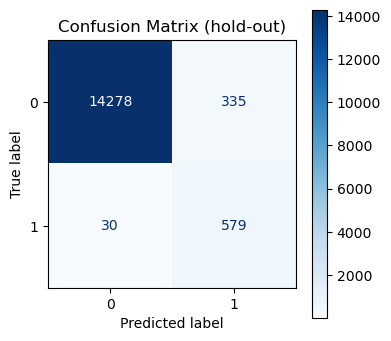

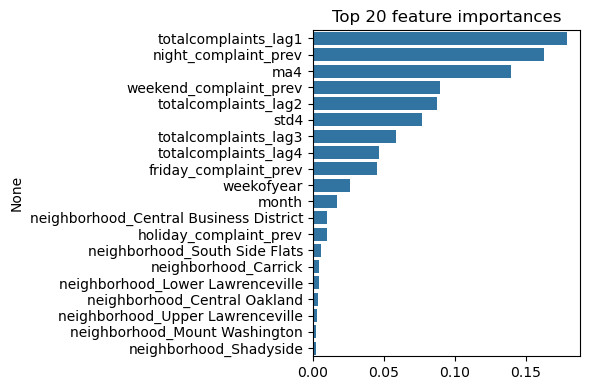

In [73]:
fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (hold‑out)')
plt.show()

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:20]
plt.figure(figsize=(6,4))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Top 20 feature importances')
plt.tight_layout()
plt.show()

In [83]:
import xgboost
from xgboost import XGBClassifier
imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=imbalance_ratio,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("\n-- XGBoost Classification Report --")
print(classification_report(y_test, y_pred_xgb, target_names=['Not‑High','High']))


-- XGBoost Classification Report --
              precision    recall  f1-score   support

    Not‑High       1.00      0.99      0.99     14613
        High       0.79      0.93      0.85       609

    accuracy                           0.99     15222
   macro avg       0.89      0.96      0.92     15222
weighted avg       0.99      0.99      0.99     15222



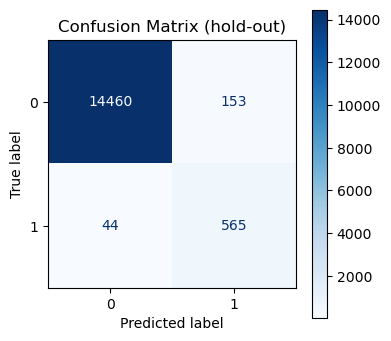

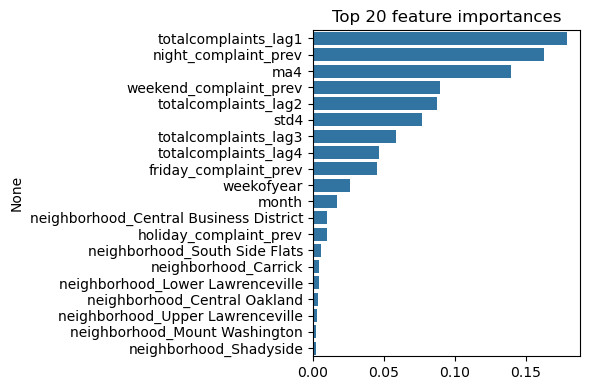

In [85]:
fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (hold‑out)')
plt.show()

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:20]
plt.figure(figsize=(6,4))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Top 20 feature importances')
plt.tight_layout()
plt.show()

In [87]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE - Training examples: {len(X_train)}")
print(f"Class distribution: {np.bincount(y_train)}")

print(f"\nAfter SMOTE - Training examples: {len(X_train_smote)}")
print(f"Class distribution: {np.bincount(y_train_smote)}")


Before SMOTE - Training examples: 60884
Class distribution: [59917   967]

After SMOTE - Training examples: 119834
Class distribution: [59917 59917]


In [89]:
clf_smote = RandomForestClassifier(random_state=42,n_estimators=600,max_depth= 8, max_features= 'sqrt')
clf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = clf_smote.predict(X_test)
y_proba_smote = clf_smote.predict_proba(X_test)

In [90]:
print("\n-- SMOTE-sampled RandomForest Classification Report --")
print(classification_report(y_test, y_pred_smote, target_names=['Not‑High','High']))


-- SMOTE-sampled RandomForest Classification Report --
              precision    recall  f1-score   support

    Not‑High       1.00      0.98      0.99     14613
        High       0.63      0.94      0.75       609

    accuracy                           0.98     15222
   macro avg       0.81      0.96      0.87     15222
weighted avg       0.98      0.98      0.98     15222



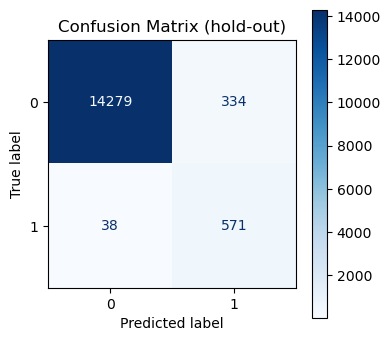

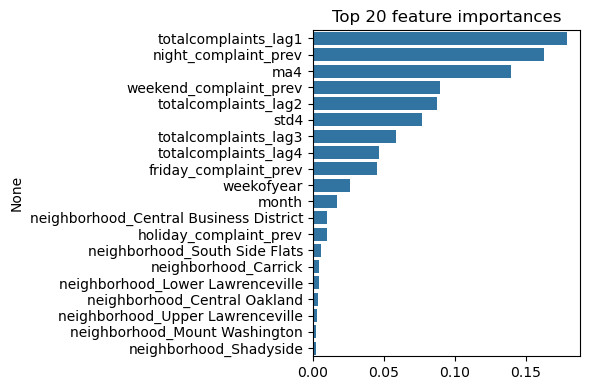

In [91]:
fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (hold‑out)')
plt.show()

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:20]
plt.figure(figsize=(6,4))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Top 20 feature importances')
plt.tight_layout()
plt.show()

In [92]:
clf_smotexgb = XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=imbalance_ratio,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
clf_smotexgb.fit(X_train_smote, y_train_smote)
y_pred_smotexgb = clf_smote.predict(X_test)
y_proba_smote = clf_smote.predict_proba(X_test)

In [93]:
print("\n-- SMOTE-sampled XGBoost Classification Report --")
print(classification_report(y_test, y_pred_smotexgb, target_names=['Not‑High','High']))


-- SMOTE-sampled XGBoost Classification Report --
              precision    recall  f1-score   support

    Not‑High       1.00      0.98      0.99     14613
        High       0.63      0.94      0.75       609

    accuracy                           0.98     15222
   macro avg       0.81      0.96      0.87     15222
weighted avg       0.98      0.98      0.98     15222



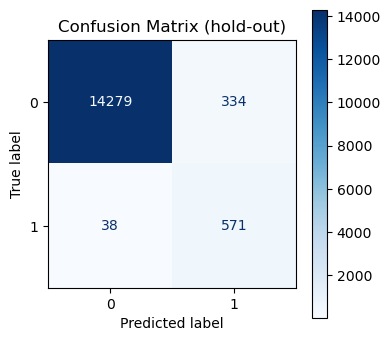

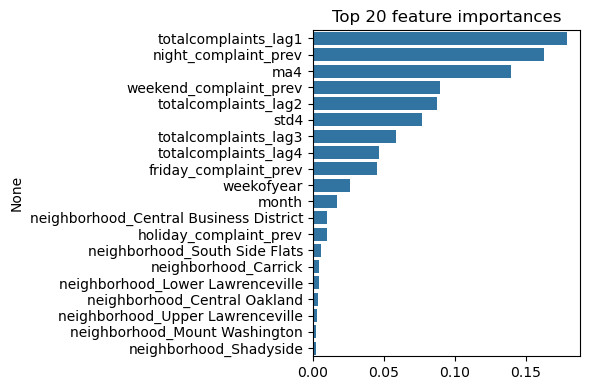

In [94]:
fig, ax = plt.subplots(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smotexgb, ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix (hold‑out)')
plt.show()

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:20]
plt.figure(figsize=(6,4))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Top 20 feature importances')
plt.tight_layout()
plt.show()

#### Model Outcome Analysis
| Model                             | Precision (High) | Recall (High) | F1-Score (High) |
|-----------------------------------|------------------|---------------|-----------------|
| Base RandomForest                 | 0.96             | 0.83          | 0.89            |
| Tuned RandomForest (GridSearch)   | 0.63             | 0.95          | 0.76            |
| XGBoost                           | 0.79             | 0.93          | 0.85            |
| SMOTE-sampled RandomForest        | 0.63             | 0.94          | 0.75            |
| SMOTE-sampled XGBoost             | 0.63             | 0.94          | 0.75            |

Of the models that we have created, Tuned RandomForest (GridSearch) performs the best in recall while Base RandomForest has the best F1 score. Note, we do not need to prioritize F1 score, but rather the recall. If we have a low Precision score, that has limited real-world consequences. Low precision score would mean that areas that have been potentially flagged with spike in their score do not actually have a spike. In the context of our policy goals, we would have more areas where we encourage communal measures of noise control when they might not actually need them. However, a low recall score would mean missing the spikes which would mean missing critical points where communal intervention needs to be established. Since XGBoost marginally outperforms RandomForest in classifying True Positives, we shall decide between SMOTE-sampled XGBoost and Tuned RandomForest (GridSearch) on the basis of how they perform in bias audits.

#### Bias Audit
**Bias Audit Rationale** \
Before operationalizing our noise‐spike detector, we must ensure it doesn’t systematically over- or under-alert in certain communities—especially those already burdened by socioeconomic or demographic disadvantage. By auditing model errors and alert rates across census‐tract attributes (e.g., median household income, percent non-white population, housing density), we guard against reinforcing existing inequities or misallocating 311 resources. This fairness check builds community trust, aligns with the city’s equity goals, and ensures that interventions reach all neighborhoods proportionally to their need rather than amplifying historic biases.

**Bias Audit Process** \
We define a `bias_table(y_true, y_pred, group_labels)` helper that loops over each non-null group in the protected attribute, computes the 2×2 confusion matrix (`tn, fp, fn, tp`), and derives recall (`tp/(tp+fn)`), false-positive rate (`fp/(fp+tn)`), and precision (`tp/(tp+fp)`). These per-group metrics are assembled into a DataFrame indexed by group and sorted by recall. Finally, for each protected column (`income_tier`, `dominant_age_group`), we apply `bias_table` to the test-set predictions and display the resulting table—enabling a clear, side-by-side comparison of model equity across demographic bins.  

In [101]:
# Bias-audit helper                                                  
def bias_table(y_true, y_pred, group_labels):
    rows = []
    for g in sorted(group_labels.dropna().unique()):
        m = group_labels == g
        if m.sum() == 0:
            continue
        # Always return a 2×2 table even if one class is missing
        tn, fp, fn, tp = confusion_matrix(
            y_true[m], y_pred[m], labels=[0, 1]
        ).ravel()
        tpr = tp / (tp + fn) if tp + fn else 0
        fpr = fp / (fp + tn) if fp + tn else 0
        prec = tp / (tp + fp) if tp + fp else 0
        rows.append(
            dict(group=g, support=m.sum(), recall=tpr, precision=prec, FPR=fpr)
        )
    return (
        pd.DataFrame(rows)
        .set_index("group")
        .sort_values("recall", ascending=False)
    )

In [103]:
y_pred = clf_smotexgb.predict(X_test)          # swap in your model name

PROTECTED_COLS = ["income_tier", "dominant_age_group"]

for col in PROTECTED_COLS:
    group_series = weeks_tracts.loc[X_test.index, col]
    print(f"\nSMOTE-sampled XGBoost Bias audit by {col}")
    display(bias_table(y_test, y_pred, group_series))


SMOTE-sampled XGBoost Bias audit by income_tier


,support,recall,precision,FPR
group,,,,
Low Income,2301,1.000000,0.341463,0.011806
Mid Income,4177,0.973770,0.755725,0.024793
High Income,8744,0.903448,0.551579,0.025195



SMOTE-sampled XGBoost Bias audit by dominant_age_group


,support,recall,precision,FPR
group,,,,
Under 25,1444,0.950000,0.600000,0.027457
Age 25–44,9045,0.948025,0.655172,0.028024
Age 45–64,2740,0.903846,0.528090,0.015625
Age 65+,1993,0.812500,0.448276,0.008093


In [105]:
y_pred = best_rf.predict(X_test)          # swap in your model name

PROTECTED_COLS = ["income_tier", "dominant_age_group"]

for col in PROTECTED_COLS:
    group_series = weeks_tracts.loc[X_test.index, col]
    print(f"\nTuned RandomForest (GridSearch) Bias audit by {col}")
    display(bias_table(y_test, y_pred, group_series))


Tuned RandomForest (GridSearch) Bias audit by income_tier


,support,recall,precision,FPR
group,,,,
Low Income,2301,1.000000,0.400000,0.009182
Mid Income,4177,0.983607,0.714286,0.030992
High Income,8744,0.913793,0.577342,0.022948



Tuned RandomForest (GridSearch) Bias audit by dominant_age_group


,support,recall,precision,FPR
group,,,,
Under 25,1444,0.966667,0.585859,0.029624
Age 25–44,9045,0.958420,0.654830,0.028375
Age 45–64,2740,0.923077,0.521739,0.016369
Age 65+,1993,0.750000,0.631579,0.003541


<b>Verdict:</b> Clearly, the Tuned RandomForest outperforms the Smote-Sampled XGBoost in bias auditing. Hence, the final model we decide is the Tuned RandomForest (GridSearch).

#### Important Caveats and Conclusion
1. There is a lack of data points on noise to begin with, which means it would be difficult to generalize this model for other cities where noise is a more prevalent problem. We would need to retrain the model for another context.
2. Noise complaints are often underreported so 311 data does not necessarily capture all the instances of noise in the area.
3. For now our focus was on more than 2 complaints, which might not exactly be a "burden" on the city's resources. However, we believe that this analysis can be extended to other areas where noise is more prevalent.
4. GridSearch could also be implemented for the SMOTE samples. However, it took up a lot of computing power and time due to which we were unable to explore that option. There is a scope for potentially better models for this policy problems.

This project presents a prototype for analyzing a city/county's noise problems on a granular level. When the time and space where noise complaints are likely to occur are identified, the city can focus on designing more context-specific measures which can be adopted by the community. Additionally, knowing the time period beforehand lets people be good neighbors and preemptively avoid causing an inconvenience. Entities like bars and public spaces can also take up more proactive measures to ensure that the complaints are avoided to their fullest extent. \
Moreover, it is important to analyze this prediction for bias. Areas with more vulnerable people should not be underrepresented in the prediction. Our model performs well in low income and younger areas, which will allow the policymakers to tinker on communal awareness that is specific to their circumstances. 